# Orbital convergence testing

In order to properly verify that the basis functions are being employed properly, in this notebook, we will demonstrate that the orbital solutions converge two different flattened halo systems as we iterate over $\ell_{\rm{max}}$. We will use the same orbital conditions. 


In [85]:
import tstrippy
import matplotlib.pyplot as plt 
import numpy as np 
from astropy import units as u 
from astropy import constants as const 
import datetime

## Helper functions

In [86]:
def make_a4_three_panel_layout(
    width_ratios=(1, 1/20, 3/4),
    cbar_right_gap_ratio=1/5,
    page_width_in=8.27,      # A4 width in inches
    margin_left_in=1.0,
    margin_right_in=1.0,
    fig_height_in=3.35,
    dpi=150,
):
    """
    Create a 1x4 GridSpec layout with one spacer column:
      [left axis | colorbar axis | spacer | right axis]

    Design goals:
    - Figure width fits A4 with normal margins.
    - Colorbar axis touches the left axis window (no horizontal gap).
    - A controlled gap exists between colorbar and right panel.

    Returns
    -------
    fig, ax_left, ax_cbar, ax_right
    """
    usable_width = page_width_in - margin_left_in - margin_right_in
    if usable_width <= 0:
        raise ValueError("Margins are too large for the page width.")

    fig = plt.figure(figsize=(usable_width, fig_height_in), dpi=dpi)

    # left/right margins converted into figure fractions
    left = margin_left_in / page_width_in
    right = 1.0 - (margin_right_in / page_width_in)

    left_ratio, cbar_ratio, right_ratio = width_ratios

    gs = fig.add_gridspec(
        nrows=1,
        ncols=4,
        width_ratios=[left_ratio, cbar_ratio, cbar_right_gap_ratio, right_ratio],
        left=left,
        right=right,
        bottom=0.12,
        top=0.95,
        wspace=0.0,
    )

    ax_left = fig.add_subplot(gs[0, 0])
    ax_cbar = fig.add_subplot(gs[0, 1])
    ax_right = fig.add_subplot(gs[0, 3])

    # Colorbar ticks/labels on the right
    ax_cbar.yaxis.set_ticks_position("right")
    ax_cbar.yaxis.set_label_position("right")

    # Right panel y ticks/labels on the right
    ax_right.yaxis.tick_right()
    ax_right.yaxis.set_label_position("right")

    return fig, ax_left, ax_cbar, ax_right


## Halo properties 

set halo properties for the exponential_oblate_halo. Pick q=0.5
Compute the characteristic time 

In [87]:
# USER PICKS HALO PROPERTIES
q       =   0.1  # flattening
s0      =   14   # scale length
Mtot    =   1e12 # characterisitic mass

## Computed
rho0 = 3 * Mtot / (4*np.pi * s0**3)
unitV = u.km/u.s
unitG = unitV**2 * (u.kpc / u.Msun)
G = const.G.to(unitG).value
params  = [G,rho0,s0,q]
staticgalaxy = ["exponential_oblate_halo", params]
Tchar = 1/ np.sqrt(G*rho0) 
print("Crossing time:", "{:.2e}".format((Tchar * u.s * (u.kpc/u.km)).to(u.yr)))
print("Char density:", "{:.2e}".format(rho0), "Msun/kpc^3")

Crossing time: 5.05e+07 yr
Char density: 8.70e+07 Msun/kpc^3


## Orbital initial conditions 

set the initial conditions for the orbit using apoapsis_shot 

In [88]:
potential   = tstrippy.potentials.exponential_oblate_halo
params      = [G,rho0,s0,q]
radius      = 2*s0
eccen       = 0.5
theta       = np.pi/4
phi         = 0 
polar_mix   = 0 
rvec,vvec   = tstrippy.code.orbits.apoapsis_shot(potential=potential,params=params,radius=radius,eccen=eccen,theta=theta,phi=phi,polar_mix=polar_mix)
initial_kinematics = [[rvec[0]],[rvec[1]],[rvec[2]],[vvec[0]],[vvec[1]],[vvec[2]]]

## integration parameters 
 compute the timestep and dynamical time based on the properties of the system 

In [89]:
dt = Tchar/1e4
integration_time = 20*Tchar
NSTEPS = int(integration_time/dt)
integration_time = NSTEPS*dt
t_years=integration_time*(u.s * (u.kpc/u.km)).to(u.yr)
dt_years=dt*(u.s * (u.kpc/u.km)).to(u.yr)
print("{:25s}: {:.2e} years".format("total integration time", t_years))
print("{:25s}: {:.2e} years".format("integration time step", dt_years))
print("{:25s}: {:d} ".format("NSTEPS", NSTEPS))
integration_params = [0,dt,NSTEPS]

total integration time   : 1.01e+09 years
integration time step    : 5.05e+03 years
NSTEPS                   : 200000 


## Integrate 
Explore changing $\ell_{\rm{max}}$

In [90]:
lmaxes = np.arange(2,50,2)
rmin,rmax,nr = 1e-4, 1e3, int(1e2)
comptimes = np.zeros_like(lmaxes)
rgrid = np.logspace(np.log10(rmin),np.log10(rmax),nr)
results = np.zeros((lmaxes.shape[0],6,NSTEPS+1))

In [ ]:
for i in range(lmaxes.shape[0]):
    starttime = datetime.datetime.now()
    tstrippy.integrator.deallocate()
    tstrippy.integrator.clearaxisymmetricbasisexpansion()
    tstrippy.integrator.initaxisymmetricbasisexpansion(G,lmaxes[i],rgrid)
    tstrippy.integrator.setinitialkinematics(*initial_kinematics)
    tstrippy.integrator.setintegrationparameters(*integration_params)
    tstrippy.integrator.setstaticgalaxy(*staticgalaxy)
    xt,yt,zt,vxt,vyt,vzt=tstrippy.integrator.leapfrogintime(NSTEPS,1)
    xt,yt,zt,vxt,vyt,vzt=xt[0],yt[0],zt[0],vxt[0],vyt[0],vzt[0]
    timestamps = tstrippy.integrator.timestamps.copy()
    endtime=datetime.datetime.now()
    comptime = endtime-starttime
    comptimes[i]=comptime.microseconds
    results[i][0]=xt
    results[i][1]=yt
    results[i][2]=zt
    results[i][3]=vxt
    results[i][4]=vyt
    results[i][5]=vzt
R = np.sqrt(np.sum(results[:,0:2,:]**2,axis=1))

# Convergence analysis 

Perform a convergence analysis. Compare all cases to the reference, which is $\ell_{\rm{max}}=50$


In [112]:
# get the density map 
def density_oblate_halo(params,x,y,z):
    rho,s,q = params
    R = np.sqrt(x**2 + y**2)
    return rho * np.exp(-(1/s) * np.sqrt((R**2 + (z/q)**2)))

In [113]:
npoints = 100
zmax = np.max(np.abs(results[-1][-1][:]))
Rs = np.linspace(0,R.max(),npoints)
zs = np.linspace(-zmax,zmax,npoints)
RS,ZS = np.meshgrid(Rs,zs,indexing="xy")
RHO = np.zeros_like(RS)
for i in range(npoints):
    RHO[i] = density_oblate_halo([rho0,s0,q],RS[i],np.zeros_like(Rs), ZS[i])

/var/folders/vt/72vlp8hj577dnzr1gl35j41c0000gn/T/ipykernel_13172/222660090.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap("rainbow")
/var/folders/vt/72vlp8hj577dnzr1gl35j41c0000gn/T/ipykernel_13172/222660090.py:13: RuntimeWarning: invalid value encountered in divide
  RMS = np.sqrt(np.sum(np.abs(diff**2 / results[-1]),axis=0))
/var/folders/vt/72vlp8hj577dnzr1gl35j41c0000gn/T/ipykernel_13172/222660090.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmapDensity = plt.cm.get_cmap("magma")


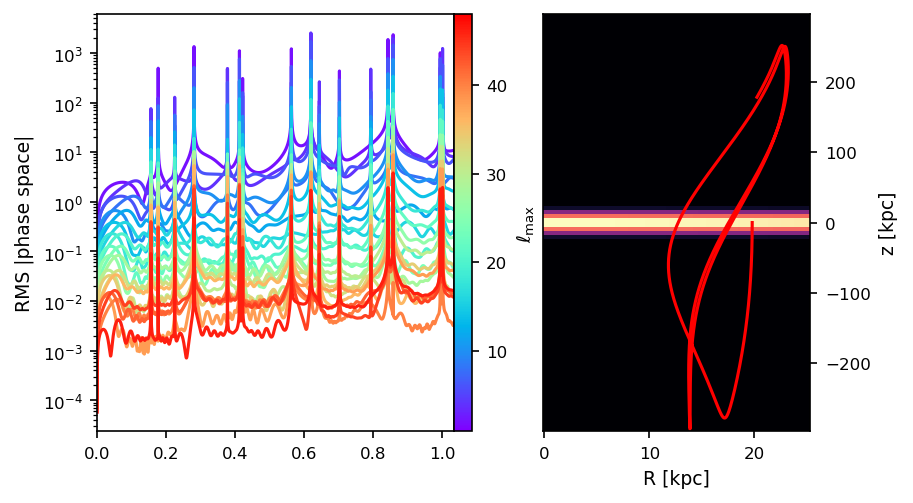

In [119]:
# colors for the l_max
cmap=plt.cm.get_cmap("rainbow")
norm=plt.cm.colors.Normalize(vmin=1,vmax=lmaxes[-1])
colors = [cmap(norm(myl)) for myl in lmaxes ]

fig, ax_left, ax_cbar, ax_right = make_a4_three_panel_layout()
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=ax_cbar)
cbar.set_label(r"$\ell_{\rm{max}}$")
for i in range(lmaxes.shape[0]-1):
    diff = results[i] - results[-1]
    RMS = np.sqrt(np.sum(np.abs(diff**2 / results[-1]),axis=0))
    ax_left.plot(timestamps,RMS,color=colors[i])
ax_left.set_yscale("log")
ax_left.set_xlim(timestamps[0],timestamps[-1])
ax_left.set_ylabel("RMS |phase space|")

# add some trajectories
ax_right.plot(R[-1],results[-1][-1],color=colors[-1])
ax_right.scatter(R[-1][0],results[-1][-1][0],color=colors[-1])
# ax_right.set_aspect("equal")
ax_right.set_xlabel("R [kpc]")
ax_right.set_ylabel("z [kpc]")
ax_right.pcolormesh(RS, ZS, RHO, shading="auto")
cmapDensity = plt.cm.get_cmap("magma")
logNorm = plt.cm.colors.LogNorm(1e1,RHO.max())
ax_right.pcolormesh(RS, ZS, RHO, shading="auto", cmap=cmapDensity, norm=logNorm)

